In [53]:
# ==============================
# 📦 IMPORTS
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score, roc_curve)

sns.set_theme(style="whitegrid")

In [7]:
# ==============================
# 📂 LOAD DATA
# ==============================
df = pd.read_csv(r"D:\Python\Data Science Projects\InsightForge AI\data\ecommerce_customer_churn_dataset.csv")

print("Initial Shape:", df.shape)
print("Columns:\n", df.columns)
df.head()

Initial Shape: (50000, 25)
Columns:
 Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [8]:
# ==============================
# 🧹 CLEANING
# ==============================
df.drop_duplicates(inplace=True)

# Fill missing values smartly
df.fillna(df.median(numeric_only=True), inplace=True)

In [9]:
# ------------------------------
# HANDLE NUMERICAL NULLS SMARTLY
# ------------------------------
num_cols = [
    'Age', 'Membership_Years', 'Login_Frequency',
    'Session_Duration_Avg', 'Pages_Per_Session',
    'Cart_Abandonment_Rate', 'Wishlist_Items',
    'Total_Purchases', 'Average_Order_Value',
    'Days_Since_Last_Purchase', 'Discount_Usage_Rate',
    'Returns_Rate', 'Email_Open_Rate',
    'Customer_Service_Calls', 'Product_Reviews_Written',
    'Social_Media_Engagement_Score',
    'Mobile_App_Usage', 'Payment_Method_Diversity',
    'Lifetime_Value', 'Credit_Balance'
]

# Median imputation (robust to outliers)
for col in num_cols:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

C:\Users\GC584\AppData\Local\Temp\ipykernel_3796\2547469786.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [10]:
# ------------------------------
# HANDLE CATEGORICAL NULLS
# ------------------------------
cat_cols = ['Gender', 'Country', 'City', 'Signup_Quarter']

for col in cat_cols:
    if col in df.columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\GC584\AppData\Local\Temp\ipykernel_3796\681177309.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [11]:
# ------------------------------
# OUTLIER TREATMENT (IQR CAPPING 🔥)
# ------------------------------
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower,
              np.where(df[col] > upper, upper, df[col]))

for col in num_cols:
    if col in df.columns:
        cap_outliers(df, col)


In [12]:
# ------------------------------
# SKEWNESS CORRECTION (LOG TRANSFORM 🔥)
# ------------------------------
skew_cols = ['Total_Purchases', 'Lifetime_Value', 'Credit_Balance']

for col in skew_cols:
    if col in df.columns:
        df[col] = np.log1p(df[col])

d:\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
d:\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [13]:
# ------------------------------
# FEATURE NORMALIZATION (RATES CHECK)
# ------------------------------
rate_cols = [
    'Cart_Abandonment_Rate',
    'Discount_Usage_Rate',
    'Returns_Rate',
    'Email_Open_Rate'
]

for col in rate_cols:
    if col in df.columns:
        # Ensure values are between 0 and 1
        df[col] = df[col].clip(0, 1)

In [14]:
# ------------------------------
# CONSISTENCY CHECKS (VERY IMPORTANT)
# ------------------------------

# Age sanity
df = df[(df['Age'] >= 18) & (df['Age'] <= 80)]

# Remove impossible negative values
for col in num_cols:
    if col in df.columns:
        df = df[df[col] >= 0]

In [15]:
# ------------------------------
# DERIVED CLEAN FEATURE (ADVANCED)
# ------------------------------

# Purchase intensity (NEW FEATURE 🔥)
df['purchase_intensity'] = df['Total_Purchases'] / (df['Membership_Years'] + 1)

# Behavioral stability score
df['stability_score'] = (
    df['Session_Duration_Avg'] * df['Pages_Per_Session']
)


In [17]:
print("Final Shape:", df.shape)
df.head()

Final Shape: (49930, 27)


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter,purchase_intensity,stability_score
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,1.0,3.0,...,4.0,16.3,20.8,1.0,6.861010,7.731492,0,Q1,0.590406,164.40
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,1.0,1.0,...,3.0,27.6,23.3,3.0,6.973983,8.015988,0,Q4,1.161702,439.81
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,1.0,1.0,...,1.0,27.6,8.8,2.0,7.162979,7.748460,0,Q4,0.592958,39.68
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,1.0,9.0,...,5.0,78.8,31.0,3.0,7.758726,7.891705,0,Q1,0.770164,568.32
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.4,1.0,9.0,...,8.5,78.8,41.7,4.0,8.020366,8.500047,0,Q4,0.841460,431.76


In [18]:
# ==============================
# 🔥 FEATURE ENGINEERING
# ==============================

# Recency
df['recency_score'] = pd.qcut(df['Days_Since_Last_Purchase'], 4, labels=[4,3,2,1])

# Frequency
df['frequency_score'] = pd.qcut(df['Total_Purchases'].rank(method='first'), 4, labels=[1,2,3,4])

# Monetary
df['monetary_score'] = pd.qcut(df['Average_Order_Value'], 4, labels=[1,2,3,4])

# RFM
df['RFM_score'] = (
    df['recency_score'].astype(int) +
    df['frequency_score'].astype(int) +
    df['monetary_score'].astype(int)
)

# 🔥 Advanced Engagement Score (UNIQUE)
df['engagement_score'] = (
    df['Login_Frequency'] +
    df['Session_Duration_Avg'] +
    df['Pages_Per_Session'] +
    df['Email_Open_Rate'] +
    df['Social_Media_Engagement_Score']
) / 5

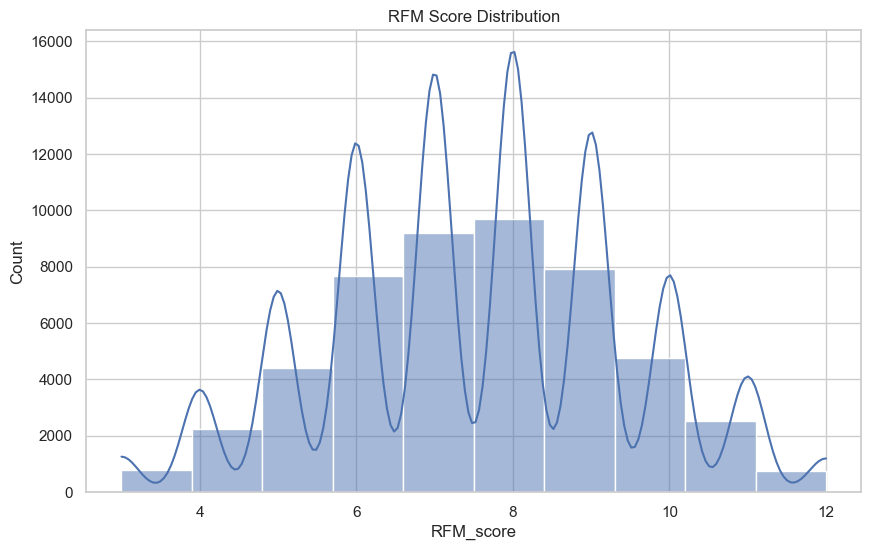

In [27]:
# ==============================
# 📊 VISUALIZATION 1 — RFM
# ==============================
plt.figure(figsize=(10,6))
sns.histplot(df['RFM_score'], bins=10, kde=True)
plt.title("RFM Score Distribution")
plt.show()

In [20]:
# ==============================
# ⚙️ ENCODING
# ==============================
df_encoded = pd.get_dummies(df, drop_first=True)

# ==============================
# ⚙️ SCALING
# ==============================
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    df_encoded.select_dtypes(include=['int64','float64'])
)

df_scaled = pd.DataFrame(
    scaled_features,
    columns=df_encoded.select_dtypes(include=['int64','float64']).columns
)

In [21]:
# ==============================
# 🔵 SEGMENTATION
# ==============================
features = df_scaled[['Membership_Years', 'Total_Purchases', 'RFM_score']]

kmeans = KMeans(n_clusters=4, random_state=42)
df['segment'] = kmeans.fit_predict(features)

# Labeling
def label_segment(row):
    if row['RFM_score'] >= 10:
        return "High Value"
    elif row['RFM_score'] >= 7:
        return "Potential Loyalists"
    elif row['RFM_score'] >= 5:
        return "At Risk"
    else:
        return "Low Value"

df['segment_label'] = df.apply(label_segment, axis=1)

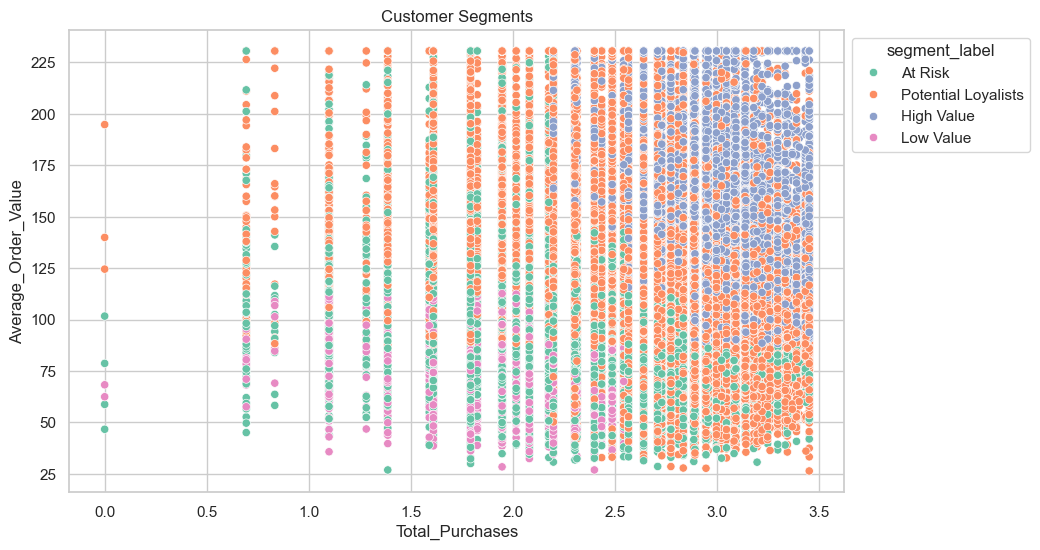

In [26]:
# ==============================
# 📊 VISUALIZATION 2 — SEGMENTS
# ==============================
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=df['Total_Purchases'],
    y=df['Average_Order_Value'],
    hue=df['segment_label'],
    palette='Set2'
)
plt.title("Customer Segments")
plt.legend(
    title="segment_label",
    bbox_to_anchor=(1, 1),
    loc='upper left'
)

plt.show()

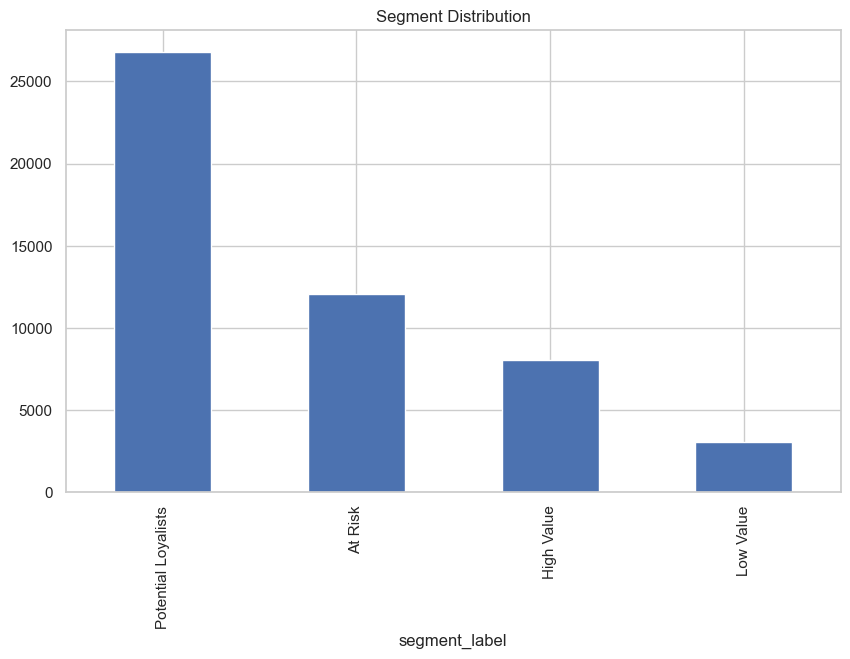

In [29]:
# ==============================
# 📊 VISUALIZATION 3 — SEGMENT DISTRIBUTION
# ==============================
plt.figure(figsize=(10, 6))
df['segment_label'].value_counts().plot(kind='bar')
plt.title("Segment Distribution")
plt.show()

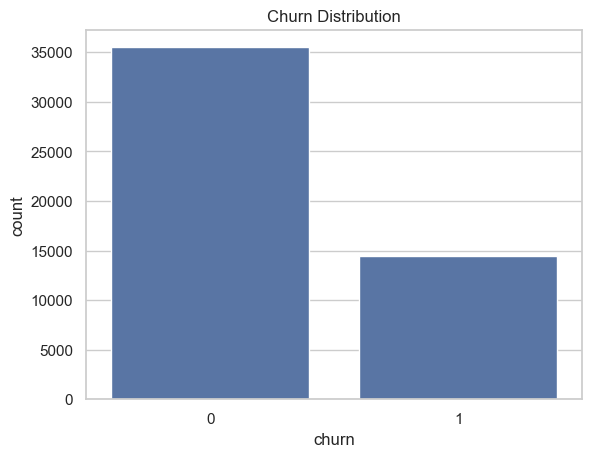

In [30]:
# ==============================
# 🔴 CHURN
# ==============================
df['churn'] = df['Churned']

# ==============================
# 📊 VISUALIZATION 4 — CHURN
# ==============================
plt.figure()
sns.countplot(x=df['churn'])
plt.title("Churn Distribution")
plt.show()

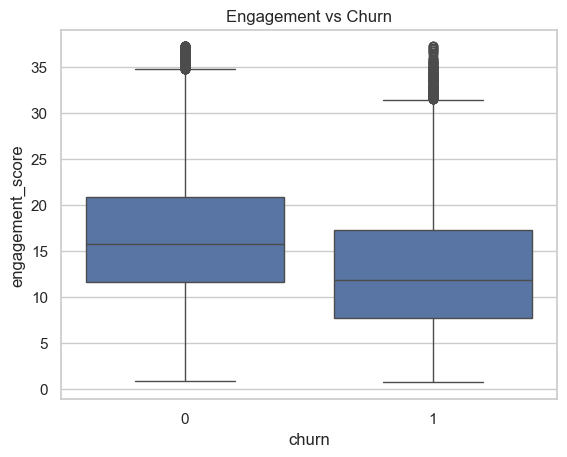

In [31]:
# ==============================
# 📊 VISUALIZATION 5 — ENGAGEMENT VS CHURN
# ==============================
plt.figure()
sns.boxplot(x=df['churn'], y=df['engagement_score'])
plt.title("Engagement vs Churn")
plt.show()

In [54]:
# ==============================
# 🔥 ADVANCED FEATURE ENGINEERING
# ==============================

# Risk score
df['risk_score'] = (
    df['Cart_Abandonment_Rate'] +
    df['Returns_Rate'] +
    df['Customer_Service_Calls']
) / 3

# Loyalty score
df['loyalty_score'] = (
    df['Membership_Years'] +
    df['Total_Purchases']
) / 2

# Friction score
df['friction_score'] = (
    df['Cart_Abandonment_Rate'] +
    df['Returns_Rate']
) / 2

# Support intensity
df['support_intensity'] = (
    df['Customer_Service_Calls'] /
    (df['Total_Purchases'] + 1)
)

# Value efficiency
df['value_per_purchase'] = (
    df['Lifetime_Value'] /
    (df['Total_Purchases'] + 1)
)

# ==============================
# 🎯 FEATURE SELECTION (STRONG ONLY)
# ==============================

features = [
    'RFM_score',
    'engagement_score',
    'risk_score',
    'loyalty_score',
    'friction_score',
    'support_intensity',
    'value_per_purchase'
]

X = df[features]
y = df['churn']

In [55]:
# ==============================
# ✂️ TRAIN TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [56]:
# ==============================
# ⚖️ HANDLE IMBALANCE
# ==============================

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

In [57]:
# ==============================
# 🚀 XGBOOST MODEL
# ==============================

model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

d:\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:00:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [58]:
# ==============================
# 🎯 PREDICTIONS
# ==============================

y_prob = model.predict_proba(X_test)[:, 1]

# 🔥 THRESHOLD TUNING
threshold = 0.45
y_pred = (y_prob > threshold).astype(int)

In [59]:
# ==============================
# 📊 CLASSIFICATION REPORT
# ==============================

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.74      0.80      7013
           1       0.55      0.75      0.64      2973

    accuracy                           0.75      9986
   macro avg       0.71      0.75      0.72      9986
weighted avg       0.78      0.75      0.75      9986



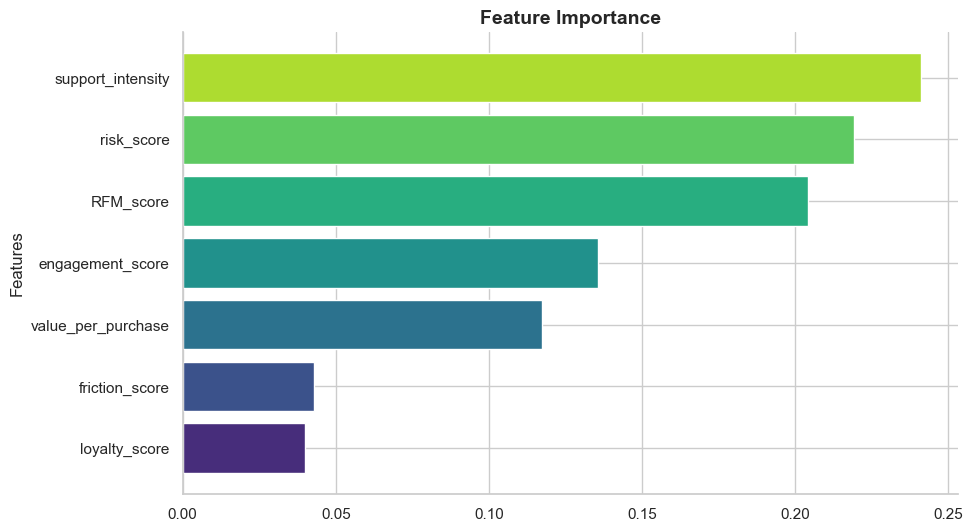

In [ ]:
# ==============================
# 📊 FEATURE IMPORTANCE
# ==============================

importances = pd.Series(model.feature_importances_, index=features)
importances_sorted = importances.sort_values()

plt.figure(figsize=(10,6))
# Color gradient (🔥 looks premium)
colors = sns.color_palette("viridis", len(importances_sorted))
# Horizontal barplot
plt.barh(importances_sorted.index, importances_sorted.values, color=colors)
# Titles and labels
plt.title("Feature Importance", fontsize=14, fontweight='bold')
plt.ylabel("Features")
sns.despine()
plt.show()

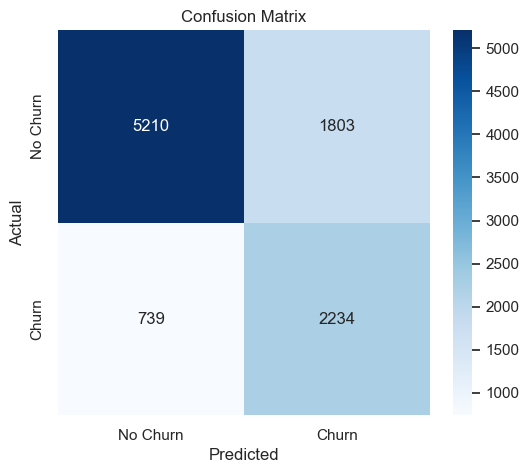

In [60]:
# ==============================
# 📊 CONFUSION MATRIX
# ==============================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ROC-AUC Score: 0.8168285231084705


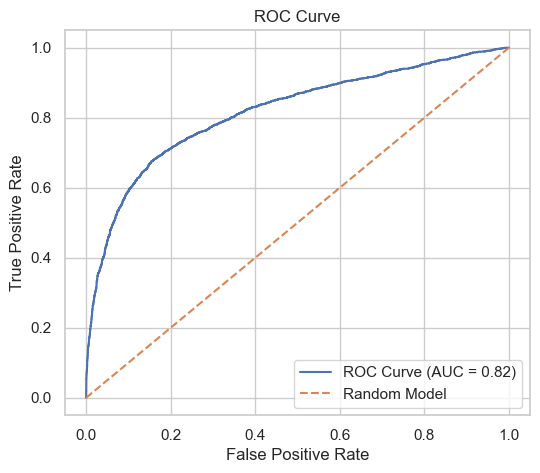

In [62]:
# ==============================
# 📈 ROC-AUC
# ==============================

roc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_score)

# ==============================
# 📈 ROC CURVE
# ==============================

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_score:.2f})')
plt.plot([0,1], [0,1], linestyle='--', label='Random Model')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc='lower right')

plt.grid(True)
plt.show()

In [69]:
# ==============================
# 💾 SAVE
# ==============================
df.to_csv(r"D:\Python\Data Science Projects\InsightForge AI\data\processed_data.csv", index=False)

In [ ]:
import joblib

joblib.dump(model, r"D:\Python\Data Science Projects\InsightForge AI\model\xgboost_model.pkl")

joblib.dump(features, r"D:\Python\Data Science Projects\InsightForge AI\model\features.pkl")


['D:\\Python\\Data Science Projects\\InsightForge AI\\model\\features.pkl']

In [71]:
df.head(50).to_csv(r"D:\Python\Data Science Projects\InsightForge AI\data\sample_input.csv", index=False)

df[['churn_probability', 'segment_label']].to_csv(
    r"D:\Python\Data Science Projects\InsightForge AI\data\model_outputs.csv", index=False
)